In [1]:
MODEL_CLS = "neumf"
DATASET = "movielens"
STRATEGY = "pairwise"
PATH_WORK_DIR = "../.."

In [ ]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
else:
    raise ValueError()

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\03_OCCF\01_RS-BPR


In [5]:
import sys
sys.path.append("src")

# Config

In [6]:
import pandas as pd
from pairwise import config, datamodule, trainer, evaluator, utils
import lfm

In [7]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [8]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 610
number of item: 9724
total interaction: 100836
interaction density: 1.7000 %
max interaction of user: 2698
max interaction of item: 329
top 10.0 % interaction of user: 400.3
top 10.0 % interaction of item: 27.0
mean interaction of user: 165
mean interaction of item: 10


In [11]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, _ = datamodule.build(**kwargs)

# Modeling

In [12]:
kwargs = dict(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["gmf"].params,
)

gmf_cls = lfm.gmf.GeneralMatrixFactorization(**kwargs)

In [13]:
kwargs = dict(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["ncf"].params,
)

ncf_cls = lfm.ncf.NeuralCollaborativeFiltering(**kwargs)

In [14]:
kwargs = dict(
    gmf=gmf_cls,
    mlp=ncf_cls,
)

model = lfm.neumf.NeuralMatrixFactorization(**kwargs)

# Train

In [15]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [16]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 39
BEST SCORE: 0.5696


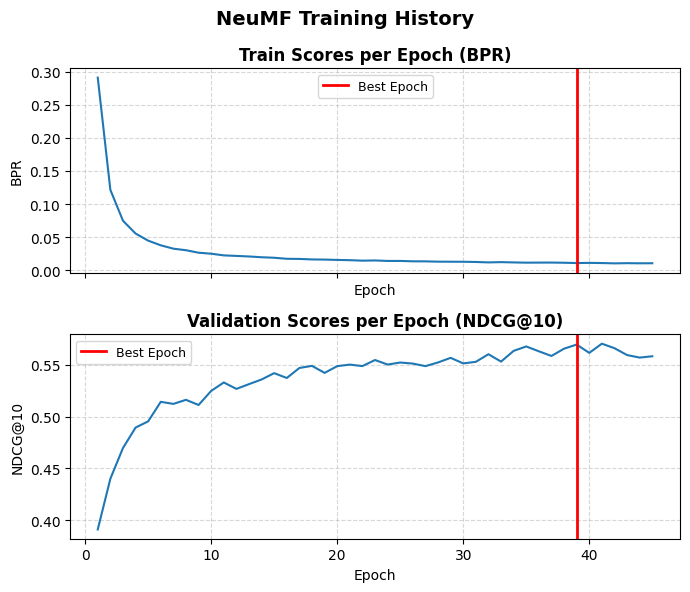

In [17]:
kwargs = dict(
    records=records,
    suptitle="NeuMF Training History",
    trn="BPR",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [18]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [19]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 986/986 [00:02<00:00, 405.45it/s]


In [20]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.900000,0.472131,0.316510,0.249314,0.550402
1,10,0.947541,0.365902,0.439966,0.307248,0.547989
2,15,0.962295,0.307869,0.512261,0.333123,0.556094
3,20,0.975410,0.264180,0.557145,0.346372,0.559833
4,25,0.977049,0.233967,0.597594,0.356752,0.565824
5,50,0.998361,0.153738,0.706840,0.379285,0.587166


# Save

In [21]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)